# 1. 标题与学习目标：DeepLOB 注释版

对应论文：**DeepLOB: Deep Convolutional Neural Networks for Limit Order Books**  
论文链接（arXiv）：https://arxiv.org/abs/1808.03668

本节采用 annotated 风格：先解释论文中的建模动机与数据定义，再紧跟对应代码实现。读者不需要先完整阅读论文，也可以沿着“金融含义 -> 张量形状 -> PyTorch 实现 -> 结果解释”的路径运行本 notebook。

本节要解决的核心问题：

- 如何把 FI-2010 的原始 LOB 数据组织成可训练的监督学习样本
- DeepLOB 为什么只使用前 40 维 raw LOB，且如何构造成 `(num_samples, 100, 40)`
- CNN、Inception 与 LSTM 分别对应论文中的哪一类市场微观结构信号
- 如何完成一个可复现的训练-验证-测试闭环并解读结果

学习完成后，你将能够：

- 说清楚 LOB 数据在本任务中的输入输出定义
- 理解样本如何从 `(149, N)` 转换为 `(num_samples, 1, 100, 40)`
- 解释 DeepLOB 中卷积、Inception 与 LSTM 的张量流动
- 跑通一个最小可复现实验，并读懂 loss/acc 与分类报告


## 2. 研究背景与直觉

DeepLOB 面向的是限价订单簿（Limit Order Book, LOB）预测问题。订单簿记录了买卖双方在不同价格档位上的挂单数量，是高频交易中最直接的市场微观结构数据。

论文的核心判断是：盘口不是普通表格特征，而是一个随 event 演化的二维结构。

- 同一时刻的 10 档买卖盘反映流动性分布、买卖压力与价差结构
- 连续多个 event 的盘口序列反映短期订单流变化
- 未来中间价方向可以看成对这段盘口序列的三分类预测

因此，DeepLOB 使用 CNN 提取局部价量结构，用 Inception 捕捉不同时间尺度的模式，再用 LSTM 建模更长的序列依赖。


In [1]:
%%bash
# download data
set -euo pipefail
DATA_URL="https://raw.githubusercontent.com/zcakhaa/DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books/master/data/data.zip"
DATA_DIR="data"
ZIP_PATH="data.zip"
if [[ -d "$DATA_DIR" ]]; then
  echo "data/ already exists, skip download."
else
  wget --progress=bar:force:noscroll -O "$ZIP_PATH" "$DATA_URL"
  unzip -q -o "$ZIP_PATH" -d "./data"
  echo "Data prepared in data/."
fi


data/ already exists, skip download.


## 3. 数据集与任务定义

本 notebook 使用 **FI-2010** 限价订单簿基准数据集，并参照论文 *DeepLOB: Deep Convolutional Neural Networks for Limit Order Books* 的实验设置。

`data/` 目录中的典型文件包括：

- `data/Train_Dst_NoAuction_DecPre_CF_7.txt`（训练）
- `data/Test_Dst_NoAuction_DecPre_CF_7.txt`、`data/Test_Dst_NoAuction_DecPre_CF_8.txt`、`data/Test_Dst_NoAuction_DecPre_CF_9.txt`（测试）

这些 txt 通常是“**按行存特征**、**按列存时间事件**”的矩阵，而不是“每行一个样本”。如果原矩阵记为 `raw_data`，形状是 `(149, N)`：

- 前 40 行：raw LOB，来自 10 档盘口价量，转置后为 `(N, 40)`
- 第 40 到 143 行：handcrafted features，本 notebook 不作为 DeepLOB 输入
- 最后 5 行：不同预测 horizon 的标签，转置后为 `(N, 5)`

前 40 维的顺序可以理解为：

`[ask_p1, ask_v1, bid_p1, bid_v1, ..., ask_p10, ask_v10, bid_p10, bid_v10]`

把单个 event 的 10 档限价订单簿展开成表格时，每一档包含卖盘价格、卖盘数量、买盘价格和买盘数量。`ask_p1/bid_p1` 是最靠近中间价的第一档，档位越大，价格离当前最优报价越远。

价格大小关系需要分买卖两侧理解：

- 卖盘（ask）是市场中愿意卖出的限价单，第一档是最低卖价，所以 `ask_p1 <= ask_p2 <= ... <= ask_p10`。
- 买盘（bid）是市场中愿意买入的限价单，第一档是最高买价，所以 `bid_p1 >= bid_p2 >= ... >= bid_p10`。
- 正常订单簿中，最优买价不会高于最优卖价，因此 `bid_p1 <= ask_p1`。二者差值 `ask_p1 - bid_p1` 是买卖价差（bid-ask spread）。
- 如果用中间价表示当前价格中心，常见定义是 `mid_price = (ask_p1 + bid_p1) / 2`。

因此，10 档盘口的价格从低到高可以粗略理解为：

`bid_p10 <= ... <= bid_p2 <= bid_p1 <= ask_p1 <= ask_p2 <= ... <= ask_p10`

| 档位 | 卖盘价格 | 卖盘数量 | 买盘价格 | 买盘数量 | 价格关系 | 对应 40 维字段 |
|---:|---|---:|---|---:|---|---|
| 1 | `ask_p1` | `ask_v1` | `bid_p1` | `bid_v1` | 最低卖价 / 最高买价 | 0-3 |
| 2 | `ask_p2` | `ask_v2` | `bid_p2` | `bid_v2` | `ask_p2 >= ask_p1`，`bid_p2 <= bid_p1` | 4-7 |
| 3 | `ask_p3` | `ask_v3` | `bid_p3` | `bid_v3` | `ask_p3 >= ask_p2`，`bid_p3 <= bid_p2` | 8-11 |
| 4 | `ask_p4` | `ask_v4` | `bid_p4` | `bid_v4` | `ask_p4 >= ask_p3`，`bid_p4 <= bid_p3` | 12-15 |
| 5 | `ask_p5` | `ask_v5` | `bid_p5` | `bid_v5` | `ask_p5 >= ask_p4`，`bid_p5 <= bid_p4` | 16-19 |
| 6 | `ask_p6` | `ask_v6` | `bid_p6` | `bid_v6` | `ask_p6 >= ask_p5`，`bid_p6 <= bid_p5` | 20-23 |
| 7 | `ask_p7` | `ask_v7` | `bid_p7` | `bid_v7` | `ask_p7 >= ask_p6`，`bid_p7 <= bid_p6` | 24-27 |
| 8 | `ask_p8` | `ask_v8` | `bid_p8` | `bid_v8` | `ask_p8 >= ask_p7`，`bid_p8 <= bid_p7` | 28-31 |
| 9 | `ask_p9` | `ask_v9` | `bid_p9` | `bid_v9` | `ask_p9 >= ask_p8`，`bid_p9 <= bid_p8` | 32-35 |
| 10 | `ask_p10` | `ask_v10` | `bid_p10` | `bid_v10` | 最高卖价 / 最低买价 | 36-39 |

最后 5 个标签通常对应未来 10、20、30、50、100 个 event 的中间价方向。这里使用 `horizon_index=4`，即预测未来 100 个 event 的方向。


### 3.1 从论文数据到 PyTorch 样本

论文将连续盘口片段作为模型输入。代码里用滑动窗口把逐 event 特征切成长度为 `T=100` 的序列：

- `prepare_x(raw_data)`：取前 40 行并转置，得到 `(N, 40)`
- `get_label(raw_data)`：取最后 5 行并转置，得到 `(N, 5)`
- `build_sequence_samples(...)`：构造 `(num_samples, 100, 40)`
- `DeepLOBDataset.__getitem__`：返回 `(1, 100, 40)`，供 CNN 作为单通道输入

这里的四个维度金融含义是：

- `B`：batch 中的样本数
- `1`：盘口序列被视为单通道“图像”
- `T=100`：过去 100 个 event
- `F=40`：10 档盘口的 ask/bid 价量


In [2]:
import numpy as np
import torch
from torch.utils import data


# -----------------------------
# 1. 特征与标签提取
# -----------------------------
def prepare_x(raw_data):
    """提取前 40 行 raw LOB 特征，并转置为 (N, 40)。"""
    return raw_data[:40, :].T


def get_label(raw_data):
    """提取最后 5 行标签，并转置为 (N, 5)。"""
    return raw_data[-5:, :].T


# -----------------------------
# 2. 滑动窗口样本构造
# -----------------------------
def build_sequence_samples(features, labels, window_size):
    """将逐时刻特征切成长度为 window_size 的序列样本。"""
    num_events, feature_dim = features.shape
    num_samples = num_events - window_size + 1

    sample_x = np.zeros((num_samples, window_size, feature_dim))
    sample_y = labels[window_size - 1:num_events]

    for idx in range(window_size, num_events + 1):
        sample_x[idx - window_size] = features[idx - window_size:idx, :]

    return sample_x, sample_y


# -----------------------------
# 3. PyTorch 数据集
# -----------------------------
class DeepLOBDataset(data.Dataset):
    """DeepLOB 的 PyTorch Dataset，输出形状为 (1, T, 40)。"""

    def __init__(self, raw_data, horizon_index=4, num_classes=3, window_size=100):
        self.horizon_index = horizon_index
        self.num_classes = num_classes
        self.window_size = window_size

        features = prepare_x(raw_data)
        labels = get_label(raw_data)
        features, labels = build_sequence_samples(features, labels, window_size)

        # 将标签从 {1, 2, 3} 映射到 {0, 1, 2}
        labels = labels[:, horizon_index] - 1

        self.x = torch.from_numpy(features).unsqueeze(1).float()
        self.y = torch.from_numpy(labels).long()
        self.length = len(self.x)

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        return self.x[index], self.y[index]


# -----------------------------
# 4. 读取原始 txt 文件
# -----------------------------
train_raw = np.loadtxt('data/Train_Dst_NoAuction_DecPre_CF_7.txt')
test_raw_7 = np.loadtxt('data/Test_Dst_NoAuction_DecPre_CF_7.txt')
test_raw_8 = np.loadtxt('data/Test_Dst_NoAuction_DecPre_CF_8.txt')
test_raw_9 = np.loadtxt('data/Test_Dst_NoAuction_DecPre_CF_9.txt')

# 按时间顺序切分训练集：前 80% 做训练，后 20% 做验证
split_idx = int(np.floor(train_raw.shape[1] * 0.8))
train_raw_split = train_raw[:, :split_idx]
val_raw_split = train_raw[:, split_idx:]

# 将 3 个测试文件按列拼接成完整测试集
test_raw = np.hstack((test_raw_7, test_raw_8, test_raw_9))

print('原始矩阵形状：')
print('train_raw       =', train_raw.shape)
print('train_raw_split =', train_raw_split.shape)
print('val_raw_split   =', val_raw_split.shape)
print('test_raw_7      =', test_raw_7.shape)
print('test_raw_8      =', test_raw_8.shape)
print('test_raw_9      =', test_raw_9.shape)
print('test_raw        =', test_raw.shape)




原始矩阵形状：
train_raw       = (149, 254750)
train_raw_split = (149, 203800)
val_raw_split   = (149, 50950)
test_raw_7      = (149, 55478)
test_raw_8      = (149, 52172)
test_raw_9      = (149, 31937)
test_raw        = (149, 139587)


### 3.2 用表格查看单个 event 的 10 档盘口

下面把第一个 event 的前 40 维 raw LOB 还原成 10 行表格。这个表格对应一个时间点的盘口截面：每一行是一档限价队列，列表示该档的卖盘价格、卖盘数量、买盘价格和买盘数量。


In [3]:
class LOBTable:
    """在 Jupyter 中用 HTML 表格展示盘口，普通 Python 中退化为文本表格。"""

    def __init__(self, rows):
        self.rows = rows

    def _repr_html_(self):
        header = '<tr><th>档位</th><th>卖盘价格 ask_p</th><th>卖盘数量 ask_v</th><th>买盘价格 bid_p</th><th>买盘数量 bid_v</th></tr>'
        body = ''.join(
            '<tr>' + ''.join(f'<td>{value}</td>' for value in row) + '</tr>'
            for row in self.rows
        )
        return f'<table>{header}{body}</table>'

    def __repr__(self):
        lines = ['档位 | 卖盘价格 ask_p | 卖盘数量 ask_v | 买盘价格 bid_p | 买盘数量 bid_v']
        lines.append('-' * len(lines[0]))
        lines.extend(' | '.join(map(str, row)) for row in self.rows)
        return '\n'.join(lines)


def lob_event_to_table(raw_data, event_index=0):
    """将单个 event 的 40 维 LOB 特征还原为 10 档盘口表。"""
    lob_features = raw_data[:40, event_index].reshape(10, 4)
    rows = []
    for level, (ask_p, ask_v, bid_p, bid_v) in enumerate(lob_features, start=1):
        rows.append((level, ask_p, ask_v, bid_p, bid_v))
    return LOBTable(rows)


lob_event_to_table(train_raw, event_index=0)


档位,卖盘价格 ask_p,卖盘数量 ask_v,买盘价格 bid_p,买盘数量 bid_v
1,0.2615,0.00353,0.2606,0.00326
2,0.2618,0.002,0.2604,0.00682
3,0.2619,0.00164,0.2602,0.00786
4,0.262,0.00532,0.26,0.00893
5,0.2621,0.00151,0.2599,0.00159
6,0.2623,0.00837,0.2595,0.001
7,0.2625,0.0015,0.2593,0.00143
8,0.2626,0.00787,0.2591,0.00134
9,0.2629,0.00146,0.2588,0.00123
10,0.2633,0.00311,0.2579,0.00128


### 3.3 构造 DataLoader 并检查张量形状

训练文件按时间顺序切分为训练集与验证集，避免随机切分造成未来信息泄漏。测试集由多个测试文件按时间拼接。

下面的检查重点不是样本数量本身，而是输入输出形状是否和论文任务一致：

- `x`: `(num_samples, 1, 100, 40)`
- `y`: `(num_samples,)`
- 一个 batch 的 `xb`: `(B, 1, 100, 40)`
- 一个 batch 的 `yb`: `(B,)`


In [4]:
# -----------------------------
# 5. 构造 DeepLOB 数据集与 DataLoader
# -----------------------------
window_size = 100
horizon_index = 4  # 这里对应未来 100 个 event 的标签
num_classes = 3
batch_size = 64

train_dataset = DeepLOBDataset(
    train_raw_split,
    horizon_index=horizon_index,
    num_classes=num_classes,
    window_size=window_size,
)
val_dataset = DeepLOBDataset(
    val_raw_split,
    horizon_index=horizon_index,
    num_classes=num_classes,
    window_size=window_size,
)
test_dataset = DeepLOBDataset(
    test_raw,
    horizon_index=horizon_index,
    num_classes=num_classes,
    window_size=window_size,
)

print('\n样本张量形状：')
print('train_dataset.x =', train_dataset.x.shape)
print('train_dataset.y =', train_dataset.y.shape)
print('val_dataset.x   =', val_dataset.x.shape)
print('val_dataset.y   =', val_dataset.y.shape)
print('test_dataset.x  =', test_dataset.x.shape)
print('test_dataset.y  =', test_dataset.y.shape)

# 在 CUDA 下启用 pin_memory 可提升 Host -> Device 拷贝效率
pin_memory = torch.cuda.is_available()

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=pin_memory,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=pin_memory,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=pin_memory,
)

# 查看一个 batch 的形状，确认输入是否正确
xb, yb = next(iter(train_loader))
print('\n一个 batch 的形状：')
print('xb =', xb.shape)
print('yb =', yb.shape)


样本张量形状：
train_dataset.x = torch.Size([203701, 1, 100, 40])
train_dataset.y = torch.Size([203701])
val_dataset.x   = torch.Size([50851, 1, 100, 40])
val_dataset.y   = torch.Size([50851])
test_dataset.x  = torch.Size([139488, 1, 100, 40])
test_dataset.y  = torch.Size([139488])

一个 batch 的形状：
xb = torch.Size([64, 1, 100, 40])
yb = torch.Size([64])


## 4. 模型框架

DeepLOB 的主干结构可以概括为四段：

1. **卷积模块（CNN blocks）**：沿盘口宽度压缩 40 维 raw LOB，并提取相邻价量档位的局部模式。
2. **Inception 模块**：并行使用不同时间卷积核，捕捉短期与相对更长的局部时间结构。
3. **LSTM 模块**：把卷积后的每个时间步表示串起来，建模订单簿演化过程。
4. **全连接分类层**：输出三类方向概率。

从金融解释看，CNN 更关注“盘口截面结构”，LSTM 更关注“盘口随 event 演化的路径”。
下图展示了 DeepLOB 从 10 档 LOB 输入到方向分类输出的整体结构：

![DeepLOB 模型框架](images/framework.png)

In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


## 5. 模型组件与张量流动

输入张量是 `(B, 1, 100, 40)`。

- `conv1`：宽度从 40 压到 20，同时用 `(4, 1)` 卷积沿时间方向提取局部变化
- `conv2`：宽度从 20 压到 10
- `conv3`：宽度从 10 压到 1，得到按时间排列的深层盘口表示
- `inp1/inp2/inp3`：三个分支并行提取不同时间尺度模式
- 拼接后得到 `(B, 192, T', 1)`
- reshape 为 `(B, T', 192)` 后送入 LSTM
- 取最后一个时间步隐藏状态，映射到三分类输出

注意：教学实现里为了便于观察，显式写出每一层并在注释中标出形状。工程实现中也可以封装模块，但初学阶段保留展开写法更容易跟踪张量。


In [6]:
import torch
import torch.nn as nn

class deeplob(nn.Module):
    def __init__(self, y_len):
        super().__init__()
        self.y_len = y_len
        
        # convolution blocks
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,10)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        
        # inception moduels
        self.inp1 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(5,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        
        # lstm layers
        self.lstm = nn.LSTM(input_size=192, hidden_size=64, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(64, self.y_len)

    def forward(self, x):
        # x: (B, 1, T, 40)
        h0 = torch.zeros(1, x.size(0), 64).to(device)  # (1, B, 64)
        c0 = torch.zeros(1, x.size(0), 64).to(device)  # (1, B, 64)
    
        x = self.conv1(x)  # (B, 32, T-6, 20)
        x = self.conv2(x)  # (B, 32, T-12, 10)
        x = self.conv3(x)  # (B, 32, T-18, 1)
        
        x_inp1 = self.inp1(x)  # (B, 64, T-18, 1)
        x_inp2 = self.inp2(x)  # (B, 64, T-18, 1)
        x_inp3 = self.inp3(x)  # (B, 64, T-18, 1)
        
        x = torch.cat((x_inp1, x_inp2, x_inp3), dim=1)  # (B, 192, T-18, 1)
        
        x = x.permute(0, 2, 1, 3)  # (B, T-18, 192, 1)
        x = torch.reshape(x, (-1, x.shape[1], x.shape[2]))  # (B, T-18, 192)
        
        x, _ = self.lstm(x, (h0, c0))  # (B, T-18, 64)
        x = x[:, -1, :]  # (B, 64)
        x = self.fc1(x)  # (B, y_len)
        forecast_y = torch.softmax(x, dim=1)  # (B, y_len)
        
        return forecast_y

### 5.1 用模型摘要核对实现

`torchinfo.summary` 可以帮助核对每一层的输出形状。这里重点观察：

- 输入是否为 `(1, 1, 100, 40)`
- 卷积后盘口宽度是否被压缩到 1
- LSTM 输入维度是否为 192
- 最终输出是否为 3 类 logits/概率


In [7]:
from torchinfo import summary
model = deeplob(y_len = train_dataset.num_classes)
model.to(device)
summary(model, (1, 1, 100, 40))

Layer (type:depth-idx)                   Output Shape              Param #
deeplob                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 32, 94, 20]           --
│    └─Conv2d: 2-1                       [1, 32, 100, 20]          96
│    └─LeakyReLU: 2-2                    [1, 32, 100, 20]          --
│    └─BatchNorm2d: 2-3                  [1, 32, 100, 20]          64
│    └─Conv2d: 2-4                       [1, 32, 97, 20]           4,128
│    └─LeakyReLU: 2-5                    [1, 32, 97, 20]           --
│    └─BatchNorm2d: 2-6                  [1, 32, 97, 20]           64
│    └─Conv2d: 2-7                       [1, 32, 94, 20]           4,128
│    └─LeakyReLU: 2-8                    [1, 32, 94, 20]           --
│    └─BatchNorm2d: 2-9                  [1, 32, 94, 20]           64
├─Sequential: 1-2                        [1, 32, 88, 10]           --
│    └─Conv2d: 2-10                      [1, 32, 94, 10]           2,080
│    └

## 6. 损失函数定义

本节使用 `CrossEntropyLoss` 训练三分类模型。

在金融任务中，三个类别通常对应未来中间价方向：下跌、平稳、上涨。损失函数最小化的是分类误差；但量化研究中还需要进一步检查类别不平衡、不同类别的 precision/recall，以及信号是否能转化为稳定策略收益。

代码中标签已经从原始 `{1, 2, 3}` 映射为 PyTorch 需要的 `{0, 1, 2}`。


## 7. 模型训练过程

训练流程包括：

- 优化器：Adam，学习率 `1e-4`
- 每个 epoch 记录：`train_loss`、`val_loss`、`train_acc`、`val_acc`
- 保存验证集最优模型：`best_val_model_pytorch.pth`
- 保存训练历史：`training_history.json`

为了保持 notebook 阅读体验，训练函数使用单行 tqdm 进度条展示训练进度，并在进度条右侧更新当前 epoch 的 loss/acc，不逐 epoch 打印多行日志。


In [8]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm


def evaluate(model, data_loader, criterion, device):
    """在给定 data_loader 上评估 loss 和 accuracy。"""
    model.eval()
    loss_values = []
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device, dtype=torch.float, non_blocking=True)
            targets = targets.to(device, dtype=torch.int64, non_blocking=True)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss_values.append(loss.item())
            preds = outputs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

    mean_loss = float(np.mean(loss_values)) if loss_values else 0.0
    accuracy = float(correct / total) if total > 0 else 0.0
    return mean_loss, accuracy


def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """训练一个 epoch，返回 train_loss 和 train_acc。"""
    model.train()
    loss_values = []
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs = inputs.to(device, dtype=torch.float, non_blocking=True)
        targets = targets.to(device, dtype=torch.int64, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        loss_values.append(loss.item())
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

    train_loss = float(np.mean(loss_values)) if loss_values else 0.0
    train_acc = float(correct / total) if total > 0 else 0.0
    return train_loss, train_acc


def fit(model, criterion, optimizer, train_loader, val_loader, epochs, device, show_progress=True):
    """完整训练流程：每个 epoch 记录 train/val 的 loss 与 acc。"""
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
    }

    best_val_loss = np.inf
    best_val_epoch = -1

    progress = tqdm(
        range(epochs),
        desc='Training',
        disable=not show_progress,
        leave=True,
        dynamic_ncols=True,
    )

    for epoch in progress:
        epoch_start = datetime.now()

        train_loss, train_acc = train_one_epoch(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )

        val_loss, val_acc = evaluate(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
            device=device,
        )

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            torch.save(model, './best_val_model_pytorch.pth')
            best_val_loss = val_loss
            best_val_epoch = epoch
        duration = datetime.now() - epoch_start
        progress.set_postfix(
            train_loss=f'{train_loss:.4f}',
            val_loss=f'{val_loss:.4f}',
            train_acc=f'{train_acc:.4f}',
            val_acc=f'{val_acc:.4f}',
            best_epoch=best_val_epoch + 1,
            epoch_time=str(duration).split('.')[0],
        )

    return history


def plot_training_curves(history):
    """绘制训练过程中的 loss/acc 曲线。"""
    epochs = np.arange(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history['train_loss'], label='train loss')
    axes[0].plot(epochs, history['val_loss'], label='val loss')
    axes[0].set_title('Loss Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], label='train acc')
    axes[1].plot(epochs, history['val_acc'], label='val acc')
    axes[1].set_title('Accuracy Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### 7.1 最小训练示例

下面的单元会运行完整训练并绘制曲线。课堂演示或快速验证时，可以先把 `epochs` 改成较小值，例如 `2`，确认数据、模型和损失函数能连通；正式实验再增加训练轮数。

这里不直接打印完整 `history_json`，因为 50 个 epoch 的 JSON 会显著拉长 notebook 输出。训练历史已保存到 `training_history.json`，需要复盘时可以单独读取。


Training:   0%|          | 0/50 [00:00<?, ?it/s]

已保存 training_history.json。训练曲线见下图。


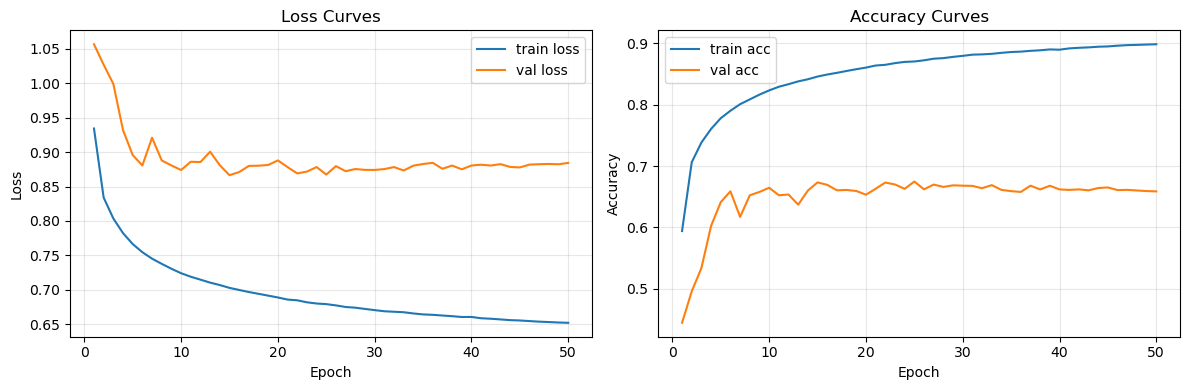

In [9]:
# 训练参数
learning_rate = 1e-4
epochs = 50

# 损失函数与优化器
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# 开始训练（使用 val_loader 作为验证集）
history = fit(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=epochs,
    device=device,
    show_progress=True,
)

# 以 JSON 形式保存训练历史；不直接打印完整 JSON，避免 notebook 输出过长
history_json = json.dumps(history, ensure_ascii=False, indent=2)
with open('training_history.json', 'w', encoding='utf-8') as f:
    f.write(history_json)

print('已保存 training_history.json。训练曲线见下图。')

# 绘制训练曲线
plot_training_curves(history)

## 8. 最小可运行示例与结果解释

评估阶段使用验证集上最优的模型权重，并在测试集上报告：

- `test_loss`：测试集平均交叉熵
- `test_acc`：方向分类准确率
- `classification_report`：每个类别的 precision、recall、f1-score

读结果时不要只看 accuracy。LOB 方向预测常见问题是类别不均衡或模型偏向某一类，因此需要同时观察三类的 recall 与 f1。若后续接入策略回测，还应加入手续费、滑点和持仓约束，而不是直接把分类准确率等同于交易收益。


In [10]:
from sklearn.metrics import accuracy_score, classification_report

# 在测试集上评估保存的最佳模型
best_model = torch.load('best_val_model_pytorch.pth', map_location=device, weights_only=False)
best_model.to(device)

# 1) 复用 evaluate 计算 loss 和 acc
test_loss, test_acc = evaluate(
    model=best_model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test acc : {test_acc:.4f}")

# 2) 收集全部标签与预测，输出 sklearn 评估报告
best_model.eval()
all_targets = []
all_predictions = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device, dtype=torch.float, non_blocking=True)
        targets = targets.to(device, dtype=torch.int64, non_blocking=True)

        outputs = best_model(inputs)
        predictions = outputs.argmax(dim=1)

        all_targets.extend(targets.cpu().numpy().tolist())
        all_predictions.extend(predictions.cpu().numpy().tolist())

print('accuracy_score:', accuracy_score(all_targets, all_predictions))
print(classification_report(all_targets, all_predictions, digits=4))

Test loss: 0.7893
Test acc : 0.7548
accuracy_score: 0.7547961114934618
              precision    recall  f1-score   support

           0     0.7285    0.7598    0.7438     47915
           1     0.8212    0.7650    0.7921     48050
           2     0.7178    0.7380    0.7277     43523

    accuracy                         0.7548    139488
   macro avg     0.7558    0.7543    0.7546    139488
weighted avg     0.7571    0.7548    0.7554    139488



## 9. 小结

本节按照论文思路完成了从 FI-2010 原始矩阵到 DeepLOB 训练评估的完整闭环：

- 数据从 `(149, N)` 转为 `(num_samples, 1, 100, 40)`
- 标签选择未来 100 个 event 的中间价方向
- CNN 提取盘口局部价量结构
- Inception 捕捉不同时间尺度的局部模式
- LSTM 建模订单簿序列演化
- 最终用测试集分类报告检查模型在不同方向类别上的表现

下一步可以围绕两个方向扩展：一是比较不同 horizon、不同窗口长度和不同模型结构；二是把预测信号接入带手续费和滑点假设的轻量回测，检验分类指标是否具备量化可交易性。
